## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import PCA

sns.set_theme(style='white')
OUTPUT_DIR = 'tables'

In [2]:
OHCO = ['film_name', 'chunk_num', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:3],
    CHUNKS = OHCO[:2],
    FILMS = OHCO[:1]
)

# Import tables
LIB = pd.read_csv('tables/LIB.csv').set_index('film_name')
CORPUS = pd.read_csv('tables/CORPUS.csv').set_index(OHCO).dropna()
VOCAB = pd.read_csv('tables/VOCAB.csv')
BOW = pd.read_csv('tables/BOW.csv', index_col=[0,1])
DTM = pd.read_csv('tables/DTM.csv', index_col=0)
TFIDF = pd.read_csv('tables/TFIDF.csv', index_col=0)
TFIDF_L2 = pd.read_csv('tables/TFIDF_L2.csv', index_col=0)

## Components/DCM/Loadings

In [3]:
pca_engine = PCA(n_components = 5)
DCM = pd.DataFrame(pca_engine.fit_transform(TFIDF), index = TFIDF.index)
DCM.columns = ['PC{}'.format(i) for i in DCM.columns]
DCM

,PC0,PC1,PC2,PC3,PC4
film_name,,,,,
castle_in_the_sky,-0.006852,-0.011115,-0.017397,0.058523,0.002069
grave_of_the_fireflies,-0.005770,-0.008334,-0.009179,-0.007776,0.001878
howls_moving_castle,-0.010102,-0.020174,0.072320,0.007676,-0.015224
kikis_delivery_service,-0.005266,-0.008250,-0.006776,-0.004504,0.000009
my_neighbor_totoro,-0.036594,0.097859,0.006432,0.001261,-0.000159
nausicaa,-0.006234,-0.009713,-0.011633,-0.006047,-0.015523
only_yesterday,-0.005082,-0.007742,-0.006857,-0.004288,0.000466
pom_poko,-0.005809,-0.009394,-0.009236,-0.009035,0.003017
ponyo,0.111365,0.024815,0.004447,0.001039,-0.000119


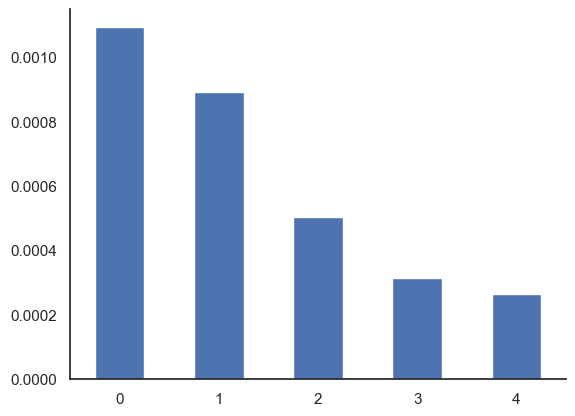

In [4]:
pd.Series(pca_engine.explained_variance_).plot.bar(rot=0)
sns.despine()
plt.show()

## Get Loadings

In [5]:
LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_),
                        index = TFIDF.columns)
LOADINGS.columns = ['PC{}'.format(i) for i in LOADINGS.columns]
LOADINGS.index.name = 'term_str'
LOADINGS

,PC0,PC1,PC2,PC3,PC4
term_str,,,,,
0,-0.000007,-0.000011,-0.000016,-0.000005,4.849045e-07
05,-0.000007,-0.000011,-0.000016,-0.000005,4.849045e-07
1,-0.000144,-0.000248,-0.000382,-0.000251,-6.075031e-04
10,-0.000025,-0.000043,-0.000073,0.000148,1.186330e-05
100,-0.000012,-0.000021,-0.000024,-0.000019,2.298898e-06
...,...,...,...,...,...
zero,-0.000008,-0.000014,-0.000017,-0.000015,7.386564e-07
zo,-0.000024,-0.000038,-0.000056,-0.000060,1.591274e-05
zohsui,-0.000012,-0.000019,-0.000028,-0.000030,7.956372e-06


### Top 5 positive in first component

In [6]:
LOADINGS['PC0'].sort_values(ascending=False).head(5)

term_str
ponyo      0.023993
sousuke    0.016175
lisa       0.008627
souchan    0.003235
koichi     0.002965
Name: PC0, dtype: float64

### Top 5 negative in second component

In [7]:
LOADINGS['PC1'].sort_values(ascending=True).head(5)

term_str
howl       -0.002442
t          -0.002425
huff       -0.001849
sophie     -0.001643
princess   -0.001253
Name: PC1, dtype: float64

In [8]:
top_terms_sk = {}
data = []
for i in range(5):
    for j in [0, 1]:
        data.append((i, j, ' '.join(LOADINGS.sort_values(f'PC{i}', ascending=bool(j)).head(5).index.to_list())))
comp_strs = pd.DataFrame(data)
comp_strs.columns =  ['pc', 'pole', 'gloss']
comp_strs = comp_strs.set_index(['pc', 'pole'])
COMPS = comp_strs.unstack()
COMPS

gloss                                      
pole                                  0                                     1
pc                                                                           
0     ponyo sousuke lisa souchan koichi         mei satsuki totoro hospital t
1      mei satsuki totoro ponyo sousuke           howl t huff sophie princess
2                howl huff t sophie ugh  sheeta princess laputa pazu raccoons
3     sheeta laputa pazu levistone mama     princess raccoons bamboo haku sen
4                haku sen t chihiro don      princess howl huff sophie bamboo

# Visualizations

In [9]:
DOC = DCM.sum(1).to_frame('n_tokens')
DOC['n_types'] = DCM.astype('bool').sum(1)
DOC['pkr'] = DOC.n_types / DOC.n_tokens
DOC = DOC.join(LIB['director'])
DOC['label']= DOC['director'].astype(str) + ' ' + DOC.index.get_level_values(0).astype(str) 
DOC

,n_tokens,n_types,pkr,director,label
film_name,,,,,
castle_in_the_sky,0.025227,5,198.197063,Miyazaki,Miyazaki castle_in_the_sky
grave_of_the_fireflies,-0.029181,5,-171.346193,Takahata,Takahata grave_of_the_fireflies
howls_moving_castle,0.034496,5,144.944191,Miyazaki,Miyazaki howls_moving_castle
kikis_delivery_service,-0.024786,5,-201.724316,Miyazaki,Miyazaki kikis_delivery_service
my_neighbor_totoro,0.068799,5,72.675511,Miyazaki,Miyazaki my_neighbor_totoro
nausicaa,-0.049149,5,-101.732232,Miyazaki,Miyazaki nausicaa
only_yesterday,-0.023504,5,-212.732731,Takahata,Takahata only_yesterday
pom_poko,-0.030457,5,-164.167722,Takahata,Takahata pom_poko
ponyo,0.141546,5,35.324092,Miyazaki,Miyazaki ponyo


In [10]:
def vis_pcs(a, b, col='label', hover_name='label'):
    return px.scatter(DCM.join(DOC), f"PC{a}", f"PC{b}", 
                    color=DOC[col], 
                    hover_name=DOC[hover_name],
                    marginal_x='box',
                    height=800)

In [11]:
def vis_loadings(LOADINGS, a=0, b=1, hover_name='term_str'):
    return px.scatter(LOADINGS.reset_index(), f"PC{a}", f"PC{b}", 
                      text='term_str', 
                      marginal_x='box', 
                      height=800)

In [12]:
vis_pcs(0, 1, col = 'director')

In [13]:
vis_loadings(LOADINGS, 0, 1)

In [14]:
vis_pcs(1, 2, col = 'director')

In [15]:
vis_loadings(LOADINGS, 1, 2)

## Save Tables

In [16]:
COMPS.to_csv(f'{OUTPUT_DIR}/COMPS.csv')
DCM.to_csv(f'{OUTPUT_DIR}/DCM.csv')
LOADINGS.to_csv(f'{OUTPUT_DIR}/LOADINGS.csv')